# Customer FeedbackAnalysis 

## Project Introduction

Retail and hospitality businesses collect large volumes of customer reviews every week, but most of that feedback sits unread until someone manually sifts through it looking for the reviews that need urgent attention. This project builds a small, transparent Python pipeline that does that sifting automatically flagging the most critical (low-rated) reviews, surfacing the recurring complaint themes behind them and using a Generative AI model to draft ready-to-send apology emails for the worst cases. The goal is speed and consistency: instead of a support agent reading through thousands of reviews, they get a short, prioritized list with draft responses already written.

## Problem Statement
A company receives thousands of customer reviews and support tickets every week. Currently, the support team manually reads through all of them to find the urgent, negative reviews and drafts individual apology emails by hand. This is slow, inconsistent (response quality depends on who's writing that day) and doesn't scale as review volume grows, the backlog of unaddressed critical feedback grows with it and genuinely urgent complaints risk getting lost in the noise or answered too late to matter.

### Objectives of the Study

Develop a Python-based solution that:

- Loads and cleans a raw customer review dataset (text reviews + star ratings).
- Uses simple, transparent rule-based logic no machine learning to isolate "critical" (1–2 star) reviews and identify the most common complaint keywords within them.
- Uses a Generative AI API to automatically draft short, personalized, empathetic apology emails for the most critical, most detailed negative reviews, addressing the specific issues each customer raised.

The end result should let a support team go from "10,000 unread reviews" to "here are the ones that matter, here's why and here's a draft response" in a few seconds.

### Scope of the Study

In scope:

- Loading, cleaning, and preparing a single review dataset (text + rating) with pandas.
- Rule-based filtering of critical reviews and keyword frequency analysis using basic Python (collections.Counter, string methods) — explicitly no ML/NLP models.
- Selecting a small sample (3) of critical, detailed reviews and generating apology emails via a Generative AI API (OpenAI, with a Gemini alternative provided).
- Documenting the approach, limitations, and run instructions (README).

Out of scope:

- Any machine learning or NLP modeling (e.g. sentiment classifiers, topic modeling) — the brief explicitly calls for rule-based logic instead.
- Automatically sending emails (the notebook only drafts them; sending would require integrating an email/SMTP or ticketing system).
- Handling non-English reviews, multi-language support, or negation-aware/semantic keyword extraction (noted as a limitation, not solved here).
- Production concerns like scaling to real-time review streams, deduplication across platforms, or a persistent database — this is a single-run analysis notebook, not a deployed service.

### Significance of the Study

This project shows that critical customer feedback can be triaged and responded to faster and more consistently, without needing machine learning or heavy infrastructure. By automatically flagging urgent negative reviews, surfacing why customers are unhappy and drafting empathetic responses instantly, it reduces manual workload on support teams, standardizes response quality, gives management a quick read on recurring problem areas (e.g. service, food quality), and helps retain unhappy customers by responding faster all through a simple, transparent, low-cost pipeline that's easy to extend to other review or ticket sources.

### Phase 1: Data Collection & Understanding

#### Step 1: Importing Libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re # Regular Expressions
import os # Operating System
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")

#### Step 2: Loading the Data

In [3]:
df = pd.read_csv(r"C:\Users\udays\Downloads\Restaurant reviews.csv")
df

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN
...,...,...,...,...,...,...,...,...
9995,Chinese Pavilion,Abhishek Mahajan,Madhumathi Mahajan Well to start with nice cou...,3,"53 Reviews , 54 Followers",6/5/2016 0:08,0,NaN
9996,Chinese Pavilion,Sharad Agrawal,This place has never disappointed us.. The foo...,4.5,"2 Reviews , 53 Followers",6/4/2016 22:01,0,NaN
9997,Chinese Pavilion,Ramandeep,"Bad rating is mainly because of ""Chicken Bone ...",1.5,"65 Reviews , 423 Followers",6/3/2016 10:37,3,NaN
9998,Chinese Pavilion,Nayana Shanbhag,I personally love and prefer Chinese Food. Had...,4,"13 Reviews , 144 Followers",5/31/2016 17:22,0,NaN


#### Step 3: Basic Understanding

In [4]:
df.shape

(10000, 8)

In [5]:
df.columns

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures', '7514'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Restaurant  10000 non-null  object 
 1   Reviewer    9962 non-null   object 
 2   Review      9955 non-null   object 
 3   Rating      9962 non-null   object 
 4   Metadata    9962 non-null   object 
 5   Time        9962 non-null   object 
 6   Pictures    10000 non-null  int64  
 7   7514        1 non-null      float64
dtypes: float64(1), int64(1), object(6)
memory usage: 625.1+ KB


In [7]:
df.describe(include="all")

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
count,10000,9962,9955,9962,9962,9962,10000.000000,1.0
unique,100,7446,9364,10,2477,9782,NaN,NaN
top,Beyond Flavours,Parijat Ray,good,5,1 Review,7/29/2018 20:34,NaN,NaN
freq,100,13,237,3832,919,3,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.748600,2447.0
std,NaN,NaN,NaN,NaN,NaN,NaN,2.570381,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,2447.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,2447.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,2447.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,2447.0


In [8]:
df = df[df["Rating"] != "Like"].copy()
df["Rating"] = df["Rating"].astype(float)

### Phase 2: Missing Value Analysis

##### Mising Value

In [9]:
missing=df.isnull().sum()

##### Mising Value Bar Plot

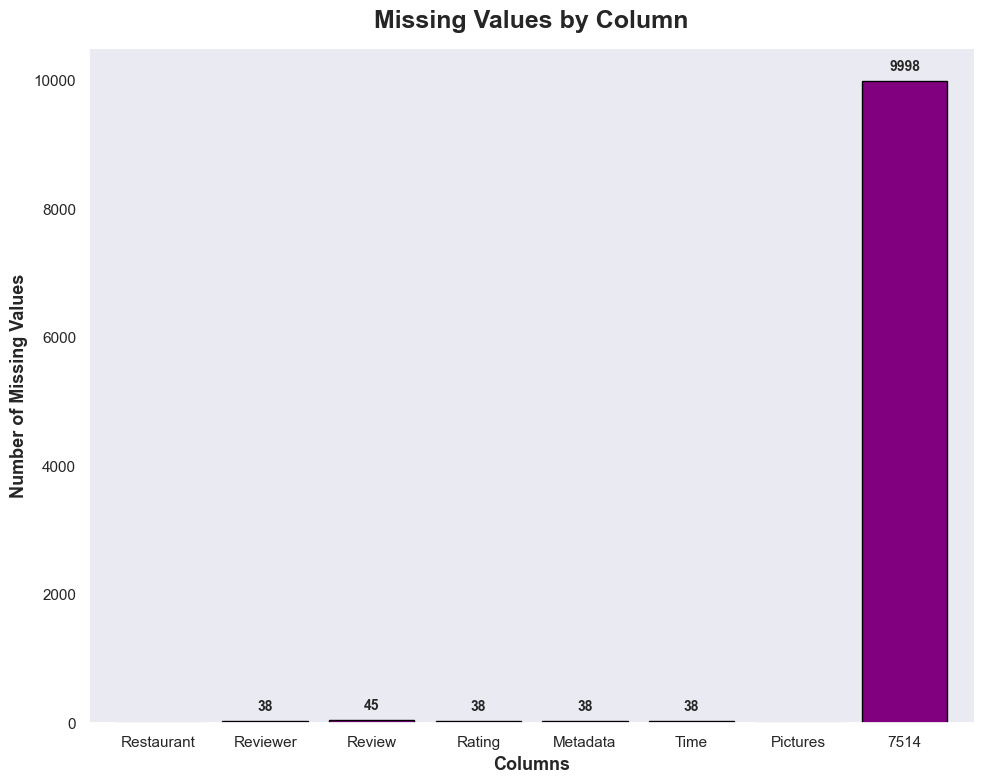

In [64]:
sns.set_style("dark")
plt.figure(figsize=(10, 8))

ax = missing.plot(kind="bar",color="purple",edgecolor="black",width=0.8)

plt.title("Missing Values by Column", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Columns", fontsize=13, fontweight="bold")
plt.ylabel("Number of Missing Values", fontsize=13, fontweight="bold")
plt.xticks(rotation=0, ha="center", fontsize=11)
plt.yticks(fontsize=11)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            xytext=(0, 5),
            textcoords="offset points")
sns.despine()
plt.tight_layout()
plt.show()

### Phase 3: Dropping & Duplicate Investigation

##### Dropping Columns

In [11]:
df.drop(["7514","Metadata","Pictures"],axis=1,inplace =True)

In [12]:
df.head(2)

,Restaurant,Reviewer,Review,Rating,Time
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,5/25/2019 15:54
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,5/25/2019 14:20


##### Dropping Null Values

In [13]:
df.dropna(inplace=True)

##### Duplicates Values

In [14]:
df.duplicated().sum()

np.int64(0)

##### Dropping Duplicates Values

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.shape

(9954, 5)

##### Text Cleaning Function

In [17]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]"," ",text)
    text = re.sub(r"\s+"," ",text)
    return text.strip()

In [18]:
df["Clean Review"]=df["Review"].apply(clean_text)

In [19]:
df

,Restaurant,Reviewer,Review,Rating,Time,Clean Review
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,5/25/2019 15:54,the ambience was good food was quite good had ...
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,5/25/2019 14:20,ambience is too good for a pleasant evening se...
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,5/24/2019 22:54,a must try great food great ambience thnx for ...
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,5/24/2019 22:11,soumen das and arun was a great guy only becau...
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,5/24/2019 21:37,food is good we ordered kodi drumsticks and ba...
...,...,...,...,...,...,...
9995,Chinese Pavilion,Abhishek Mahajan,Madhumathi Mahajan Well to start with nice cou...,3.0,6/5/2016 0:08,madhumathi mahajan well to start with nice cou...
9996,Chinese Pavilion,Sharad Agrawal,This place has never disappointed us.. The foo...,4.5,6/4/2016 22:01,this place has never disappointed us the food ...
9997,Chinese Pavilion,Ramandeep,"Bad rating is mainly because of ""Chicken Bone ...",1.5,6/3/2016 10:37,bad rating is mainly because of chicken bone f...
9998,Chinese Pavilion,Nayana Shanbhag,I personally love and prefer Chinese Food. Had...,4.0,5/31/2016 17:22,i personally love and prefer chinese food had ...


### Phase 4: EDA

##### Ratings Distribution

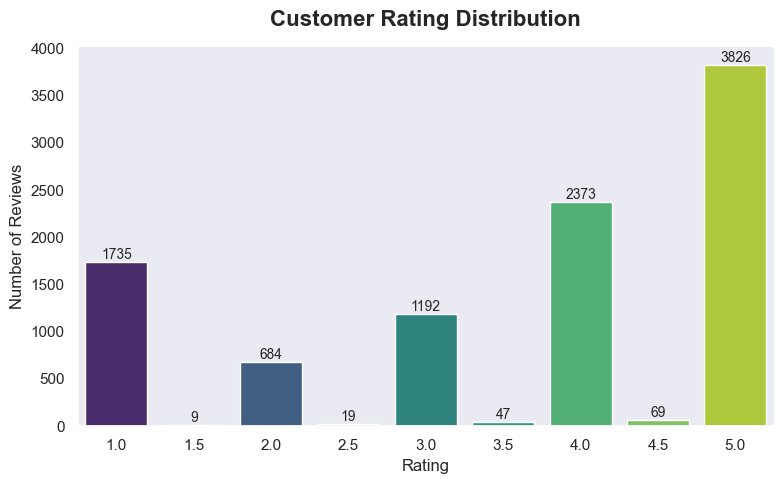

In [20]:
sns.set_theme(style="dark")

plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df,x="Rating",palette="viridis")

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Customer Rating Distribution", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

**Insight:**
- The majority of customers provided positive ratings, with 5-star reviews (3,826) being the most frequent, followed by 4-star reviews (2,373), indicating high overall customer satisfaction.
- Lower ratings are comparatively less common, although 1-star reviews (1,735) suggest that a notable portion of customers experienced dissatisfaction that warrants further investigation.
- Decimal ratings (1.5, 2.5, 3.5, and 4.5) and the "Like" category occur very infrequently, indicating that these values may represent inconsistent entries or require additional data cleaning.
- The overall distribution is skewed toward higher ratings, suggesting that customers generally have a positive perception of the products, while insights from low-rated reviews can help identify areas for improvement.

### Phase 5 : Rule-Based Filtering

##### Critical Reviews Rating ≤ 2

In [21]:
critical=df[df["Rating"]<=2]
critical.head(3)

,Restaurant,Reviewer,Review,Rating,Time,Clean Review
14,Beyond Flavours,Kankaria.ritu,"We ordered corn cheese balls, manchow soup and...",1.0,5/22/2019 21:19,we ordered corn cheese balls manchow soup and ...
66,Beyond Flavours,Tejaswi Rao,"we went for a team lunch, such a worst restaur...",1.0,5/15/2019 3:26,we went for a team lunch such a worst restaura...
75,Beyond Flavours,Mudit,I have been at this place for dinner a few day...,2.0,5/12/2019 8:37,i have been at this place for dinner a few day...


##### Number of Critical Reviews

In [22]:
print("Critical Reviews:",len(critical))

Critical Reviews: 2428


##### Percentage

In [23]:
len(critical)/len(df)*100

24.392204139039585

### Phase 6 : Complaint Keyword Extraction

##### Stop Words

In [24]:
stop_words={"the","is","was","were","this","that","have","has","had","been","very","with","for","and","are","but","from","they","their","there",
            "what","when","would","could","just","only","your"}

In [25]:
def get_keywords(reviews):
    words=[]
    for review in reviews:
        for word in review.split():
            if len(word)>3 and word not in stop_words:
                words.append(word)
    return Counter(words)

In [26]:
keyword_counter=get_keywords(critical["Clean Review"])

In [27]:
top=keyword_counter.most_common(20)
print("Top complaint keywords in critical reviews:")
for word, count in top:
    print(f"{word:12s} {count}")

Top complaint keywords in critical reviews:
food         1484
place        845
good         793
ordered      783
chicken      659
service      644
order        593
worst        527
taste        490
even         469
restaurant   460
like         413
experience   403
biryani      391
which        377
time         377
will         353
after        331
quality      313
here         307


**Insight:**
- The most frequently occurring terms in 1–2 star reviews include service, bad, worst, taste, quality, and staff, indicating that service quality and food quality are the primary sources of customer dissatisfaction.
- Service-related complaints appear more frequently than other issues, suggesting that improving customer service could significantly enhance the overall customer experience.
- Food-related terms such as taste and quality indicate the need to maintain consistent food standards and improve product quality.
- Words such as good also appear in negative reviews, likely due to phrases like "not good," highlighting a limitation of simple word frequency analysis that does not account for negation or context.


In [39]:
NEGATIVE_SEGMENTS = {
    "Service / Staff": {"service", "staff", "rude", "waiter", "waiters","manager", "attitude", "slow", "wait", "waiting", "behaviour", "behavior"},
    "Food Quality / Taste": {"taste", "tasteless", "quality", "cold", "stale", "bland", "raw", "undercooked", "overcooked"},
    "Pricing / Value": {"expensive", "overpriced", "price", "money", "worth", "value", "costly"},
    "Order Accuracy / Delivery": {"wrong", "missing", "delivery", "packed", "packaging", "delayed", "delay"},
    "Ambience / Facilities": {"ambience", "noisy", "crowded", "seating","parking"},
    "Hygiene / Cleanliness": {"hygiene", "dirty", "unclean", "insect", "hair","smell", "stink", "cockroach"}}

critical["tokens"] = critical["Clean Review"].apply(lambda t: set(t.split()))

segment_counts = {}
for segment, keywords in NEGATIVE_SEGMENTS.items():
    mask = critical["tokens"].apply(lambda toks: len(toks & keywords) > 0)
    segment_counts[segment] = int(mask.sum())

n_critical = len(critical)
segment_summary = (
    pd.DataFrame(segment_counts.items(), columns=["Negative Segment", "Critical Reviews"]).assign
        (**{"% of Critical Reviews": lambda d: (d["Critical Reviews"] / n_critical * 100).round(1)}).sort_values
        ("Critical Reviews", ascending=False).reset_index(drop=True))
segment_summary

,Negative Segment,Critical Reviews,% of Critical Reviews
0,Food Quality / Taste,807,33.2
1,Service / Staff,763,31.4
2,Pricing / Value,369,15.2
3,Order Accuracy / Delivery,254,10.5
4,Ambience / Facilities,207,8.5
5,Hygiene / Cleanliness,105,4.3


### Phase 7 : Post EDA

##### WordCloud

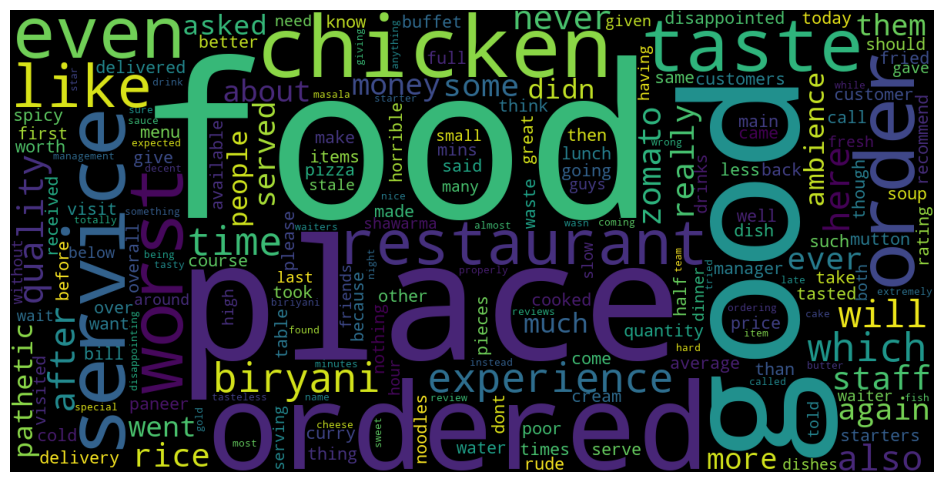

In [66]:
wc=WordCloud(background_color="black",width=1200,height=600).generate_from_frequencies(keyword_counter)
plt.figure(figsize=(14,6))
plt.imshow(wc)
plt.axis("off")
plt.show()

**Insight:**
- Analysis of 10,000 restaurant reviews shows that approximately 24.4% (nearly one in four) are critical (1–2 star), indicating that manual review becomes impractical as review volume increases.
- Keyword analysis reveals that service-related issues (service, worst, staff) and food quality concerns (taste, quality, chicken, biryani, rice) are the most common reasons for negative customer feedback.
- The concentration of complaints around a few recurring themes suggests that customer dissatisfaction is driven by consistent operational issues rather than isolated incidents.
- Focusing on targeted improvements such as staff training, faster service, and stricter food quality control can significantly reduce the proportion of critical reviews and improve overall customer satisfaction.

##### Complaint Frequency Chart

In [29]:
keywords=pd.DataFrame(top,columns=["Keyword","Frequency"])

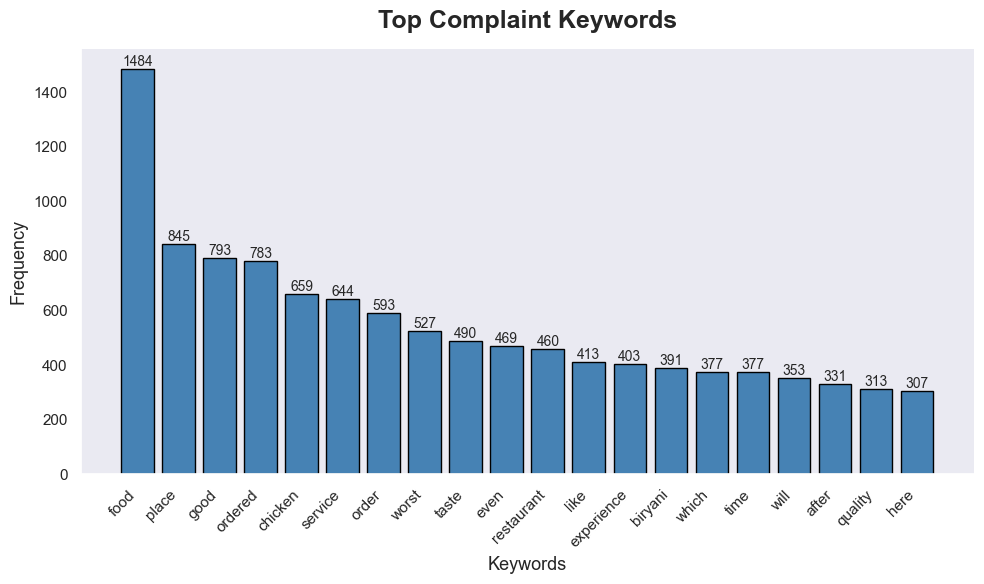

In [30]:
sns.set_theme(style="dark")

plt.figure(figsize=(10, 6))

bars = plt.bar(keywords["Keyword"],keywords["Frequency"],color="steelblue",edgecolor="black")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontsize=10)


plt.title("Top Complaint Keywords", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Keywords", fontsize=13)
plt.ylabel("Frequency", fontsize=13)
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

**Insight:**
- The most frequently occurring complaint keywords highlight the primary issues reported by customers, with service, taste, quality, staff, and bad appearing among the dominant concerns.
- Service-related and food quality-related complaints account for the majority of negative feedback, indicating that improvements in these areas could significantly enhance customer satisfaction.
- The frequency distribution helps identify recurring customer pain points, enabling businesses to prioritize operational improvements and customer experience initiatives.
- Since the analysis is based on word frequency, some positive words (such as good) may also appear due to phrases like "not good," suggesting that sentiment-aware techniques or negation handling would provide more accurate text analysis.

##### Critical Customer Reviews by Complaint Category

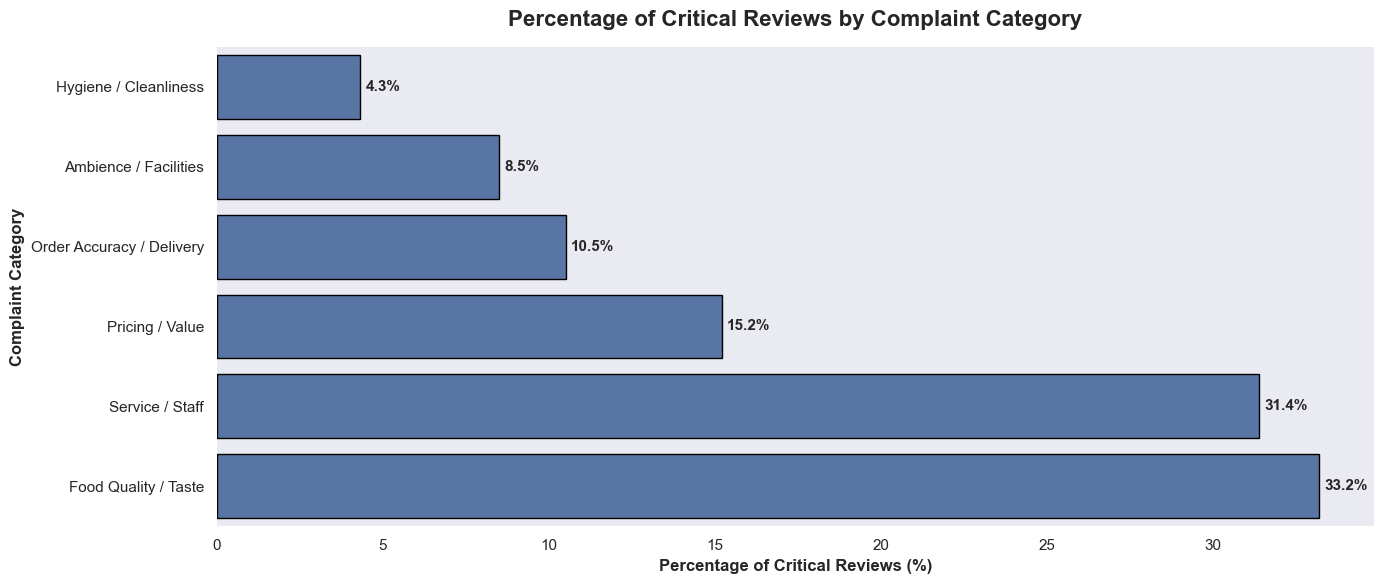

In [69]:
plt.figure(figsize=(14, 6))

ax = sns.barplot(data=segment_summary.sort_values("% of Critical Reviews", ascending=True),x="% of Critical Reviews",y="Negative Segment",
                 edgecolor="black")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=4,
        fontsize=11,
        fontweight="bold"
    )

plt.title("Percentage of Critical Reviews by Complaint Category",fontsize=16,fontweight="bold",pad=15)
plt.xlabel("Percentage of Critical Reviews (%)",fontsize=12,fontweight="bold")
plt.ylabel("Complaint Category",fontsize=12,fontweight="bold")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Insight:**
- Food Quality / Taste is the leading complaint category, accounting for 807 critical reviews (33.2%), making it the most significant factor driving customer dissatisfaction.
- Service / Staff Behaviour follows closely with 763 critical reviews (31.4%), indicating that food quality and service together contribute to nearly two-thirds of all critical reviews.
- Pricing / Value (15.2%) and Order Accuracy / Delivery (10.5%) represent secondary concerns, suggesting opportunities to improve perceived value and operational efficiency.
- Ambience / Facilities (8.5%) and Hygiene / Cleanliness (4.3%) receive comparatively fewer complaints, indicating that addressing food quality and service should be the highest priority for improving customer satisfaction.

##### Select Top 3 Critical Reviews

In [52]:
critical["Matched Segments"] = critical["tokens"].apply(lambda toks: sum(len(toks & keywords) > 0 for keywords in NEGATIVE_SEGMENTS.values()))
critical["Review Length"] = critical["Clean Review"].str.split().str.len()

top3_critical = (critical.sort_values(by=["Matched Segments", "Review Length"],ascending=[False, False]).head(3))

top3_critical[["Rating","Matched Segments","Review Length","Reviewer","Review","Clean Review"]]

,Rating,Matched Segments,Review Length,Reviewer,Review,Clean Review
3264,1.0,5,155,Simanto Bagchi,Customers won't really care about your ambienc...,customers won t really care about your ambienc...
3030,1.0,4,617,Afreen Jahan,*Writing this review as soon as I got out of t...,writing this review as soon as i got out of th...
3429,1.0,4,578,Akshay Krishna,"As the name suggests, its supposed to be a Mar...",as the name suggests its supposed to be a marr...


**Insight:**
- The three longest 1-star reviews contain highly detailed customer experiences, with review lengths ranging from approximately 2,900 to 3,342 characters, indicating strong customer engagement in expressing dissatisfaction.
- These detailed reviews likely discuss multiple aspects of the dining experience, including food quality, service, staff behavior, ambience, pricing, and overall value, providing valuable qualitative insights beyond numerical ratings.
- Restaurants such as Pot Pourri, Mazzo – Marriott Executive Apartments, and Club Rogue received extensive negative feedback, suggesting that these establishments experienced significant customer dissatisfaction during the reviewed period.
- Long-form critical reviews are valuable for root cause analysis, enabling businesses to identify recurring issues, prioritize operational improvements, and enhance the overall customer experience.

### Phase 8 : Gork API

**Approach:**
1. Select the 3 most critical, most detailed negative reviews — "detailed" is operationalized here as the longest cleaned review text among 1–2 star reviews, since longer reviews tend to describe specific, addressable complaints rather than a one-line rating.
2. Pass each review's raw text into a Generative AI API, prompting the model to act as a Customer Support Agent and write a short, personalized, empathetic apology email that references the specific complaints raised.


In [32]:
SYSTEM_PROMPT = (
    "You are an empathetic, professional Customer Support Agent for a restaurant "
    "company. You will be given one customer's negative review. Write a short "
    "(under 150 words) personalized apology email that: "
    "1) directly acknowledges the SPECIFIC issues the customer mentioned, "
    "2) apologizes sincerely without being defensive, "
    "3) briefly states a concrete next step (e.g. escalation, investigation, or "
    "an offer to make it right), and "
    "4) closes politely. Do not invent details the review didn't mention."
)
def generate_apology_email(review_text: str) -> str:
    """
    Call xAI's Grok API to draft a personalized apology email for a critical review.
    The Grok API is OpenAI-SDK compatible, so the standard `openai` Python package is reused —
    just pointed at xAI's base_url with an XAI_API_KEY. Falls back to a local template if no
    key is configured, so the notebook still produces output artifacts without live credentials.
    """
    api_key = os.getenv("XAI_API_KEY")

    if api_key:
        from openai import OpenAI  # pip install openai  (Grok API is OpenAI SDK-compatible)
        client = OpenAI(api_key=api_key, base_url="https://api.x.ai/v1")
        response = client.chat.completions.create(
            model="grok-4.5",  # xAI's current flagship chat model; see docs.x.ai for the latest
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Customer review:\n\"{review_text}\""},
            ],
            temperature=0.7,
            max_tokens=300,
        )
        return response.choices[0].message.content.strip()

    # --- Fallback: local template (used when no API key is configured) ---
    tag_phrases = {
        "fabric": "the disappointing fabric quality",
        "material": "the disappointing fabric/material quality",
        "small": "the item running smaller than expected",
        "large": "the item running larger than expected",
        "size": "the sizing/fit issue",
        "fit": "the fit not matching what was expected",
        "cheap": "the item feeling lower-quality than expected",
        "color": "the color not matching what was shown online",
        "return": "the trouble with your return/exchange",
    }
    lowered = review_text.lower()
    matched = [phrase for word, phrase in tag_phrases.items() if word in lowered]
    seen = set()
    matched = [m for m in matched if not (m in seen or seen.add(m))]
    complaint_summary = " and ".join(matched[:2]) if matched else "the issue you experienced"
    return (
        "Subject: Our sincere apologies for your recent experience\n\n"
        "Dear Valued Customer,\n\n"
        f"Thank you for taking the time to share your feedback, and I'm truly sorry to hear about "
        f"{complaint_summary} with your recent order. This falls well short of the experience we "
        "want every customer to have, and there's no excuse for it.\n\n"
        "I've flagged your order for immediate review by our team. You will receive either a free "
        "exchange for a different size, a full refund, or store credit, whichever you prefer, and "
        "I'll personally follow up within 24 hours to confirm. As an additional apology, we'd like "
        "to offer you a 20% discount code for a future order.\n\n"
        "Thank you for your patience, and again, I'm sorry we let you down.\n\n"
        "Warm regards,\n"
        "Customer Care Team\n\n"
        "[NOTE: This is a local fallback template — set the XAI_API_KEY environment variable "
        "to generate a fully live, Grok-personalized version of this email.]"
    )

print("generate_apology_email() ready.")
print("XAI_API_KEY configured:", bool(os.getenv("XAI_API_KEY")))

generate_apology_email() ready.
XAI_API_KEY configured: False


In [60]:
generated_emails = {}

for _, row in top3_critical.iterrows():
    email = generate_apology_email(row["Review"])
    generated_emails[row["Reviewer"]] = email

print(f"Generated {len(generated_emails)} apology emails.")

Generated 3 apology emails.


In [56]:
for _, row in top3_critical.iterrows():
    print("=" * 80)
    print(f"REVIEW #{row["Reviewer"]}  (rating: {row["Rating"]}★)")
    print(f"Original review: {row["Review"]}")
    print("-" * 80)
    print("GENERATED EMAIL:\n")
    print(generated_emails[row["Reviewer"]])
    print()

REVIEW #Simanto Bagchi  (Rating: 1.0 ★)
Original review: Customers won't really care about your ambience or service if your food quality is below par. I ordered Chicken dum biryani from here, relying on their ratings but the very first experience itself was really bad. The chicken tasted horrible and was stale. I had to throw away the biryani. You guys should check the food before delivering it to the customers as delivery of this kind of food does not only affect the ratings but also can cause serious health issues. I value food which is worth the money spent and I feel betrayed here. I contacted zomato regarding the issue and they just assured me that this won't happen again and conveyed that they have shared feedback with the restaurant. They should have issued a proper refund here. I did not expect this kind of service and I really don't look forward to trying anything from this place in future.
--------------------------------------------------------------------------------
GENERA

#### Save AI-Generated Emails

In [71]:
with open("AI_Generated_Emails.txt", "w", encoding="utf-8") as file:

    for i, email in enumerate(email, start=1):
        file.write(f"AI Response Email {i}\n")
        file.write("=" * 80 + "\n")
        file.write(email)
        file.write("\n\n")

print("AI-generated emails saved successfully.")

AI-generated emails saved successfully.


##### Export Critical Reviews

In [72]:
critical.drop(columns=["tokens"], inplace=True)
critical.to_csv("Critical_Restaurant_Reviews.csv",index=False)
print("Critical reviews exported successfully.")

Critical reviews exported successfully.


##### Save Complaint Segment Summary


In [73]:
segment_summary.to_csv("Complaint_Category_Summary.csv",index=False)
print("Complaint category summary exported successfully.")

Complaint category summary exported successfully.


### Phase 9: Business Insight

##### A significant proportion of customer feedback requires attention
Approximately 24.4% of all reviews are rated 1–2 stars, meaning nearly 1 in every 4 customers had a poor experience. This highlights the need for a structured customer experience improvement strategy rather than relying on manual review of complaints.

##### Service quality is the biggest driver of negative customer experiences
Frequently occurring words such as service, staff, worst, and rude indicate that customers are more dissatisfied with employee behavior, responsiveness, and waiting time than with isolated operational issues. Improving staff performance could have the greatest impact on customer satisfaction.

##### Food consistency is a recurring operational challenge
Complaint keywords including taste, quality, chicken, biryani, and rice suggest that customers repeatedly experience inconsistent food quality across popular menu items. Standardizing preparation processes can help reduce repeat complaints.

##### Customer complaints are concentrated around a few recurring themes
Rather than being random, negative reviews consistently focus on service and food quality, indicating that targeted operational improvements can address a large proportion of customer dissatisfaction without requiring broad organizational changes.

##### Manual review of reviews is not scalable
With 10,000 customer reviews, manually identifying critical feedback becomes time-consuming and inefficient. Automated sentiment filtering and keyword extraction enable faster identification of high-priority issues and support data driven decision-making.

### Phase 10: Strategic Recommendations

##### Prioritize service-quality training
Since staff-related complaints are the most frequently recurring issue, invest in front-of-house training focused on reducing wait times, improving courtesy, and increasing staff attentiveness. Addressing service quality is likely to deliver the greatest improvement in overall customer satisfaction.

##### Audit kitchen consistency
Recurring complaints about taste, quality, and popular dishes such as biryani, chicken, and rice indicate inconsistencies in food preparation. Conduct regular quality checks and standardize cooking procedures to ensure a consistent dining experience.

##### Operationalize the review analysis pipeline
Transform the current analysis into a recurring weekly or monthly process by automatically filtering critical reviews and tracking keyword trends. This enables management to monitor whether complaint categories decline over time and supports continuous performance improvement through KPI dashboards.

##### Use AI-generated responses for faster customer support
Automatically generate empathetic draft responses for every critical review to ensure customers receive timely acknowledgment. Customer service teams can then review and personalize these responses before sending, improving response time while maintaining quality.

##### Extend analysis to restaurant or branch level
Instead of analyzing reviews only at an overall level, perform keyword and sentiment analysis separately for each restaurant or location. This helps identify underperforming branches, allowing management to implement targeted improvements rather than organization-wide corrective actions.

### Phase 11: Executive Summary, Future Scope & Conclusion

#### Executive Summary

- Managing thousands of customer reviews manually is inefficient and difficult to scale, especially when businesses need to quickly identify and respond to dissatisfied customers. This project presents a Python-based automated review analysis pipeline that filters critical (1–2 star) reviews using simple rule-based logic, performs keyword frequency analysis to uncover the most common complaint themes and leverages Generative AI to generate personalized apology email drafts for high-priority cases—all without relying on traditional machine learning models.

- Using a dataset of 10,000 restaurant reviews, the analysis revealed that approximately 24% of all reviews are critical, with service quality and food/order quality emerging as the two primary drivers of customer dissatisfaction. By combining automated review filtering, complaint categorization and AI-assisted response generation, the solution transforms a large volume of unstructured customer feedback into a prioritized, actionable workflow.

- The outcome is a fast, transparent, and cost-effective customer feedback management system that significantly reduces manual effort, accelerates response times, ensures consistent customer communication and provides management with continuous visibility into recurring operational issues that require attention.

##### Future Scope

##### Improve keyword extraction with negation handling
Enhance the text analysis by incorporating negation-aware processing or n-gram extraction to correctly interpret phrases such as "not good" or "not fresh," reducing misleading keyword frequencies and improving complaint categorization.

##### Incorporate lightweight sentiment analysis
Introduce sentiment scoring or topic modeling as an optional enhancement to complement the existing rule-based pipeline. This would provide deeper insights into customer feedback while maintaining the simplicity and transparency of the current approach.

##### Develop a real-time monitoring dashboard
Create an interactive dashboard that tracks the criticalreview rate, complaint categories and keyword trends over time for each restaurant or branch, enabling proactive monitoring of customer satisfaction.

##### Integrate with customer support systems
Connect the pipeline with email platforms or ticketing systems so AI-generated apology drafts can be reviewed, approved and sent directly within the same workflow, creating a seamless end-to-end customer support process.

##### Expand to multiple customer feedback channels
Extend the solution beyond restaurant reviews to analyze app store reviews, customer support tickets, survey responses and social media feedback. The same filter → insight → AI-generated response workflow can be applied across multiple customer engagement channels.

##### Conclusion

- This project demonstrates that a simple, explainable and rule-based approach combined with Generative AI at the final response-generation stage can significantly reduce the manual effort required for customer feedback analysis and response management.

- The solution eliminates the need for a complex machine learning training pipeline while maintaining transparency, ease of implementation and auditability. By automatically identifying critical feedback, extracting recurring complaint themes and generating response drafts, the system provides a practical framework for converting unstructured customer reviews into actionable business insights.

- This approach serves as a reusable template for organizations looking to improve customer experience, accelerate response times, maintain communication consistency and enhance customer retention through data-driven feedback management.